In [1]:
%pylab inline
import corner as corner
import seaborn as sns
import matplotlib.patches as mpatches

Populating the interactive namespace from numpy and matplotlib


In [2]:
import global_imports
c = global_imports._c
G = global_imports._G
Msun = global_imports._M_s
pi = global_imports._pi
rho_ns = global_imports._rhons

In [3]:
import plotting

# tmp_color = sns.cubehelix_palette(8, start=.5, rot=-.75, dark=0.2, light=.85)[0::3]
# c_baryonic = tmp_color[:2]
# c_DE = ['#E76F51', 'xkcd:tomato']
# c_bADM = ['xkcd:violet', 'xkcd:violet']
# c_fADM = ['xkcd:azure', 'xkcd:cobalt blue']
c_dark_energy = plotting.c_dark_energy
c_bosonic = plotting.c_bosonic
c_fermionic= plotting.c_fermionic
c_baryonic = plotting.c_baryonic[1]

In [4]:
print(np.log10(1.1*rho_ns))

14.469517762679178


linestyle_tuple = [
     ('loosely dotted',        (0, (1, 10))),
     ('dotted',                (0, (1, 1))),
     ('densely dotted',        (0, (1, 1))),

     ('loosely dashed',        (0, (5, 10))),
     ('dashed',                (0, (5, 5))),
     ('densely dashed',        (0, (5, 1))),

     ('loosely dashdotted',    (0, (3, 10, 1, 10))),
     ('dashdotted',            (0, (3, 5, 1, 5))),
     ('densely dashdotted',    (0, (3, 1, 1, 1))),

     ('dashdotdotted',         (0, (3, 5, 1, 5, 1, 5))),
     ('loosely dashdotdotted', (0, (3, 10, 1, 10, 1, 10))),
     ('densely dashdotdotted', (0, (3, 1, 1, 1, 1, 1)))]

plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'serif'
plt.rcParams['font.family'] ='serif'

In [5]:
rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
rc('text', usetex=True)

pyplot.rc('text', usetex=True)
pyplot.rc('font', family='serif')

pyplot.rcParams['xtick.direction'] = 'in'
pyplot.rcParams['xtick.minor.visible'] = True
pyplot.rcParams['ytick.direction'] = 'in'
pyplot.rcParams['ytick.minor.visible'] = True
pyplot.rcParams['xtick.major.size'] = 5
pyplot.rcParams['ytick.major.size'] = 5
pyplot.rcParams['ytick.right'] = True
pyplot.rcParams['xtick.top'] = True

Generating the prior corner plot
30000
[5.48010144 6.97664978 9.50949089 ... 1.56363317 1.6450932  1.60070859]


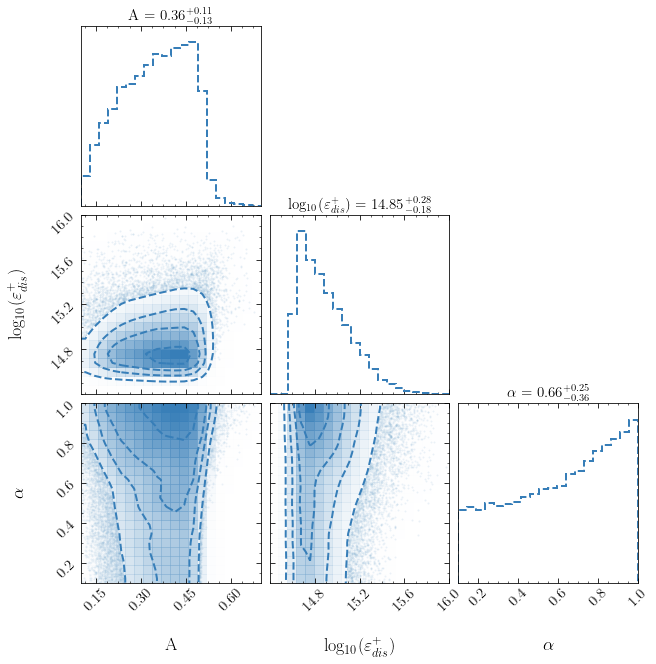

In [6]:
tmp = numpy.loadtxt('DE/Dark_energy_prior_post_equal_weights.dat')
print('Generating the prior corner plot')


print(len(tmp))
Matrix_prior = numpy.zeros((len(tmp),3))

#A_param = tmp[:,5]
#rho_plus = tmp[:,6]
#alpha = tmp[:,7]

print(tmp[:,6])
for i in range(len(tmp)):
    Matrix_prior[i] =tmp[:,5][i],numpy.log10(tmp[:,6][i]*rho_ns),tmp[:,7][i]

    


figure = corner.corner(Matrix_prior,smooth = 1.0,labels = [r"A",r"log$_{10}$($\varepsilon^+_{dis})$",r"$\alpha$"],
                      range = [(0.1,0.7),(14.4,16),(0.1,1)], show_titles = True,label_kwargs = {"fontsize":18,"font":'serif'},title_kwargs = {"fontsize":15},
                      color = '#377eb8',hist_kwargs = {'linestyle': '--','linewidth': 2.0}, contour_kwargs = {'linestyles':'dashed','linewidths': 2.0} )



figure.subplots_adjust(right=1.15,top=1.15)

for ax in figure.get_axes():
    ax.tick_params(axis='both', labelsize=15)


figure.savefig('Prior_corner_dark_energy.png',bbox_inches='tight')
#figure.savefig('PRIOR_FERMIONIC_REAL_Corner_min_mass_constraint.pdf',bbox_inches='tight')
#figure.savefig('PRIOR_FERMIONIC_REAL_Corner_min_mass_constraint.png',bbox_inches='tight')
#figure.savefig(run_name + 'Corner.pdf',dpi = 300,bbox_inches='tight')

Generating the posterior corner plot
18192


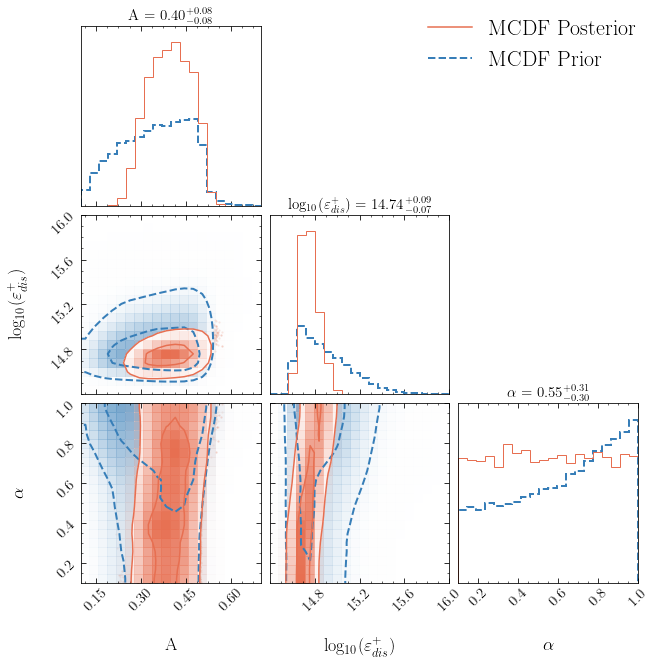

In [7]:
print('Generating the posterior corner plot')

ewposterior = numpy.loadtxt('DE/Dark_energy_posterior_post_equal_weights.dat')

#Dark_energy_posterior_max_edsc_depost_equal_weights
#Dark_energy_posterior_post_equal_weights.dat
print(len(ewposterior))


# In[5]:
A = ewposterior[:,5]
rho_plus = ewposterior[:,6]
alpha = ewposterior[:,7]
epscent_0740 = ewposterior[:,9]
#epscent_0030 = ewposterior[:,10]

Matrix = numpy.zeros((len(epscent_0740),3))
###### Everything below this needs to be fixed!####
for i in range(len(epscent_0740)):
    Matrix[i] =A[i],numpy.log10(rho_plus[i]*rho_ns),alpha[i]


Matrix = np.vstack((Matrix,Matrix))      
    
ell = corner.corner(Matrix_prior,smooth = 1.0,color = '#377eb8',group = 'prior',range = [(0.1,0.7),(14.4,16),(0.1,1)],
                   plot_datapoints = False,plot_density = True,plot_contours = True,divergences = False,levels=(0.393, 0.864),
                    hist_kwargs = {'linestyle': '--','linewidth': 2.0}, contour_kwargs = {'linestyles':'dashed','linewidths': 2.0})

#Matrix,smooth = 1.0,fig = ell,
figure = corner.corner(Matrix,smooth = 1.0,fig = ell,color = c_dark_energy,labels = [r"A",r"log$_{10}$($\varepsilon^+_{dis})$",r"$\alpha$"],
                      range = [(0.1,0.7),(14.4,16),(0.1,1)], levels=(0.393, 0.864), show_titles = True,label_kwargs = {"fontsize":18,"font":'serif'},title_kwargs = {"fontsize":15})
figure.subplots_adjust(right=1.15,top=1.15)

#quantiles =(0.001,0.999)
figure.subplots_adjust(right=1.15,top=1.15)
for ax in figure.get_axes():
    ax.tick_params(axis='both', labelsize=15) 
    
figure.legend(handles =[matplotlib.lines.Line2D([],[],color = c_dark_energy ,label = 'MCDF Posterior'),
                        matplotlib.lines.Line2D([],[],color = '#377eb8',label = 'MCDF Prior',linestyle = '--',lw = 2.0)],
                  fontsize = 22,frameon = False,loc = "upper right")


#matplotlib.lines.Line2D([],[],color = 'C1',label = 'Ground Truth',linestyle = '-')

figure.savefig('plots/Posterior_prior_corner_dark_energy.pdf',bbox_inches='tight')
#figure.savefig('POSTERIOR_FERMIONIC_REAL_07nsaturation_Corner_min_mass_constraint.png',dpi = 300,bbox_inches='tight')
#figure.savefig('FERMIONIC_LITERATURE_REAL_DATA_Corner_min_mass_constraint.jpeg',bbox_inches='tight')
#figure.savefig('POSTERIOR_FERMIONIC_REAL_07nsaturation_Corner_min_mass_constraint.pdf',bbox_inches='tight')

In [8]:
np.log10(corner.quantile(10**Matrix_prior[:,1], [0.05,0.5,0.95]))

array([14.62446231, 14.84951414, 15.33603191])

In [9]:
x = np.log10(corner.quantile(10**Matrix[:,1], [0.025,0.5,0.975]))

print(x)

[14.62914305 14.74067269 14.92891408]


Generating the prior corner plot
30000


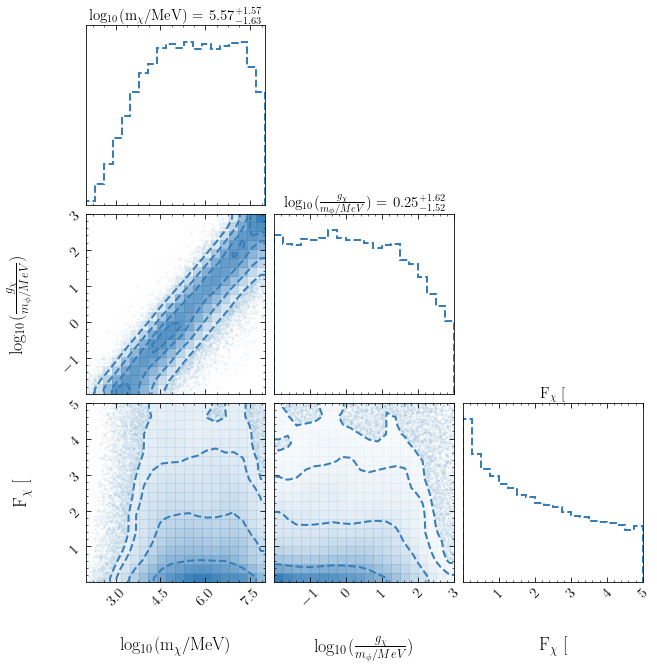

In [10]:
#ADM portion
tmp = numpy.loadtxt('BDM/Bosonic_prior_post_equal_weights.dat')
print('Generating the prior corner plot')

print(len(tmp))
Matrix_prior = numpy.zeros((len(tmp),3))

for i in range(len(tmp)):
    Matrix_prior[i] =numpy.log10(tmp[:,5][i]),numpy.log10(tmp[:,6][i]),tmp[:,7][i]
    
figure = corner.corner(Matrix_prior,smooth = 1.0,labels = [r"log$_{10}$(m$_\chi$/MeV)",r"log$_{10}$($\frac{\mathdefault{g}_\chi}{\mathdefault{m}_\phi/\mathdefault{MeV}})$",r"F$_\chi$ [%]",],
                      range = [(2,8),(-2,3),(0,5.)], show_titles = True,label_kwargs = {"fontsize":18,"font":'serif'},title_kwargs = {"fontsize":15},
                      color = '#377eb8',hist_kwargs = {'linestyle': '--','linewidth': 2.0}, contour_kwargs = {'linestyles':'dashed','linewidths': 2.0} )



figure.subplots_adjust(right=1.15,top=1.15)

for ax in figure.get_axes():
    ax.tick_params(axis='both', labelsize=15)



Generating the prior corner plot
30000
Generating the posterior corner plot
18121


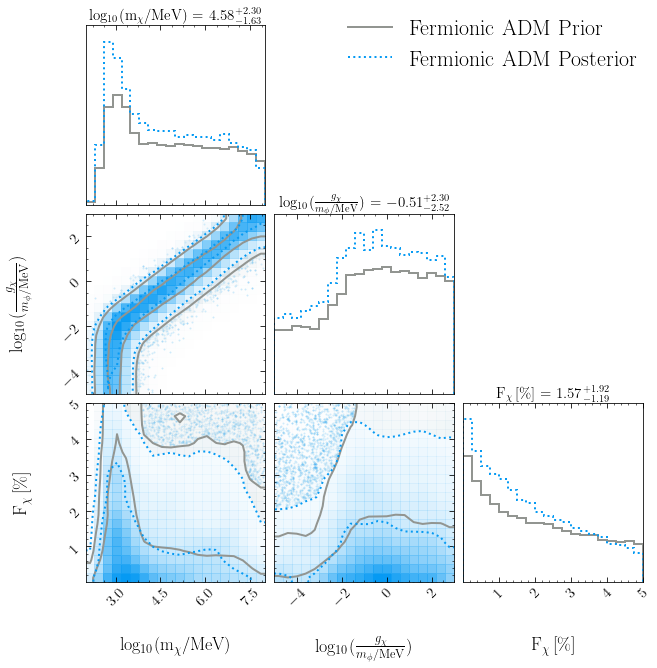

In [11]:
#ADM portion
tmp = numpy.loadtxt('FDM/Fermionic_prior_post_equal_weights.dat')
print('Generating the prior corner plot')

print(len(tmp))
Matrix_prior = numpy.zeros((len(tmp),3))

for i in range(len(tmp)):
    Matrix_prior[i] =numpy.log10(tmp[:,5][i]),numpy.log10(tmp[:,6][i]),tmp[:,7][i]
    
    
    
print('Generating the posterior corner plot')


# In[4]:


ewposterior = numpy.loadtxt('FDM/Fermionic_posterior_post_equal_weights.dat')
print(len(ewposterior))


# In[5]:




mchi = ewposterior[:,5]
gchi_over_mphi = ewposterior[:,6]
Fchi = ewposterior[:,7]
epscent_0740 = ewposterior[:,9]
epscent_0030 = ewposterior[:,10]

Matrix = numpy.zeros((len(epscent_0740),3))
###### Everything below this needs to be fixed!####
for i in range(len(epscent_0740)):
    Matrix[i] =numpy.log10(mchi[i]),numpy.log10(gchi_over_mphi[i]),Fchi[i]


Matrix = np.vstack((Matrix,Matrix)) 

ell = corner.corner(Matrix_prior,smooth = 1.0,color = 'xkcd:grey',group = 'prior',range = [(2,8),(-5,3),(0,5.)],
                   plot_datapoints = False,plot_density = True,plot_contours = True,divergences = False, levels=(0.393, 0.864),
                    hist_kwargs = {'linestyle': '-','linewidth': 2.0}, contour_kwargs = {'linestyles':'solid','linewidths': 2.0})


figure = corner.corner(Matrix,smooth = 1.0,fig = ell,color = c_fermionic,labels = [r"log$_{10}$(m$_\chi$/MeV)",r"log$_{10}$($\frac{\mathdefault{g}_\chi}{\mathdefault{m}_\phi/\mathrm{MeV}})$",r"F$_\chi \, [\%]$"],
                      range = [(2,8),(-5,3),(0,5.)],levels=(0.393, 0.864), show_titles = True,label_kwargs = {"fontsize":18,"font":'serif'},title_kwargs = {"fontsize":15},
                      hist_kwargs = {'linestyle': 'dotted','linewidth': 2.0}, contour_kwargs = {'linestyles':'dotted','linewidths': 2.0})
figure.subplots_adjust(right=1.15,top=1.15)

#quantiles =(0.001,0.999)
figure.subplots_adjust(right=1.15,top=1.15)
for ax in figure.get_axes():
    ax.tick_params(axis='both', labelsize=15) 
    
figure.legend(handles =[matplotlib.lines.Line2D([],[],color = 'xkcd:grey',label = 'Fermionic ADM Prior', linestyle = '-', lw=2.0),
                        matplotlib.lines.Line2D([],[],color = c_fermionic,label = 'Fermionic ADM Posterior',linestyle = 'dotted',lw = 2.0)],
                  fontsize = 22,frameon = False,loc = "upper right")


figure.savefig('plots/Posterior_prior_corner_fermionic_adm.pdf',bbox_inches='tight')
    

In [12]:
def get_quantiles(array, quantiles=[0.025, 0.5, 0.975]): #0.025,0.5,0.97s5 0.16,0.5,0.84
        contours = np.nanquantile(array, quantiles) #changed to nanquantile to inorder to ignore the nans that may appear
        low = contours[0]
        median = contours[1]
        high = contours[2]
        minus = low - median
        plus = high - median
        return np.round(median,2),np.round(plus,2),np.round(minus,2) 

Posteriors 68%  (-5.26, 0.69, -1.08)
Posteriors 95%  (-5.26, 1.1, -2.4)


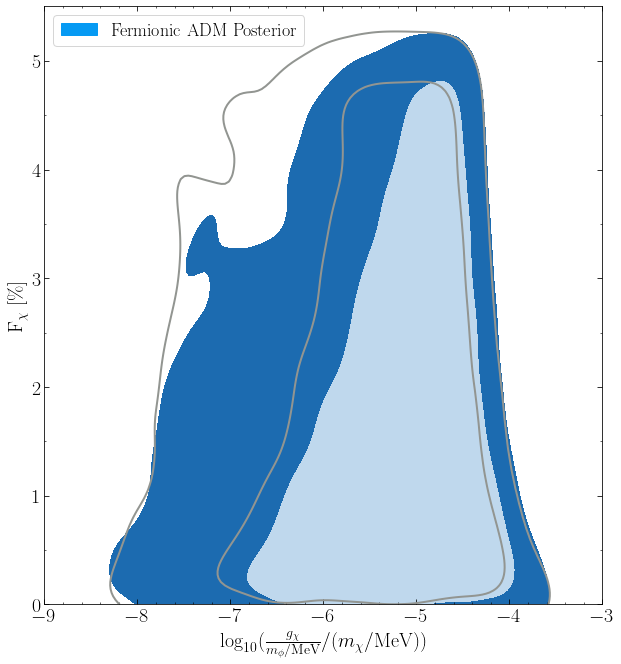

In [14]:
fig,ax = pyplot.subplots(figsize = (10,11))
my_fontsize=20
my_font = 'serif'
matplotlib.rc('font',family = my_font)
matplotlib.rcParams.update({'font.size': 20})

ratio = np.log10(10**Matrix[:,1]/10**Matrix[:,0])
print('Posteriors 68% ', get_quantiles(ratio, quantiles = [0.16,0.5,0.84]) )
print('Posteriors 95% ', get_quantiles(ratio))
plot = sns.kdeplot(x = ratio,y = Matrix[:,2],shade = True,cbar = False,cmap = 'Blues_r'
                   ,common_norm = True,levels=[0.05,0.32,1.],ax = ax)


ratio_prior = np.log10(10**Matrix_prior[:,1]/10**Matrix_prior[:,0])
plot_prior = sns.kdeplot(x = ratio_prior,y = Matrix_prior[:,2],shade = False,cbar = False,
                   colors = 'xkcd:grey',common_norm = True,levels =[0.05,0.32,1],label = "Prior", linestyles = 'solid',
                        linewidths = 2.,ax = ax)




ax.legend(handles =[mpatches.Patch(color = c_fermionic ,label = 'Fermionic ADM Posterior')],
                  fontsize = 18,frameon = True,loc = "upper left")



ax.set_yticks(numpy.arange(0, 5.5,.5),minor =True)
ax.set_xticks([-9,-8,-7,-6,-5,-4,-3])
ax.set_ylim(0.0,5.5)
ax.set_ylabel(r"F$_\chi$ [$\%$]",fontsize=my_fontsize,font = my_font)
ax.set_xlabel(r"$\log_{10}(\frac{\mathdefault{g}_\chi}{\mathdefault{m}_\phi/\mathrm{MeV}}/(\mathdefault{m}_\chi/\mathrm{MeV}))$",fontsize=my_fontsize,font = my_font)
ax.set_xlim(-9,-3)
ax.tick_params(top=1,right=1, which='both', direction='in', labelsize=my_fontsize)





fig.savefig('plots/fermionic_adm_ratio_plot.pdf',bbox_inches='tight')

Generating the prior corner plot
30000
Generating the posterior corner plot
18172


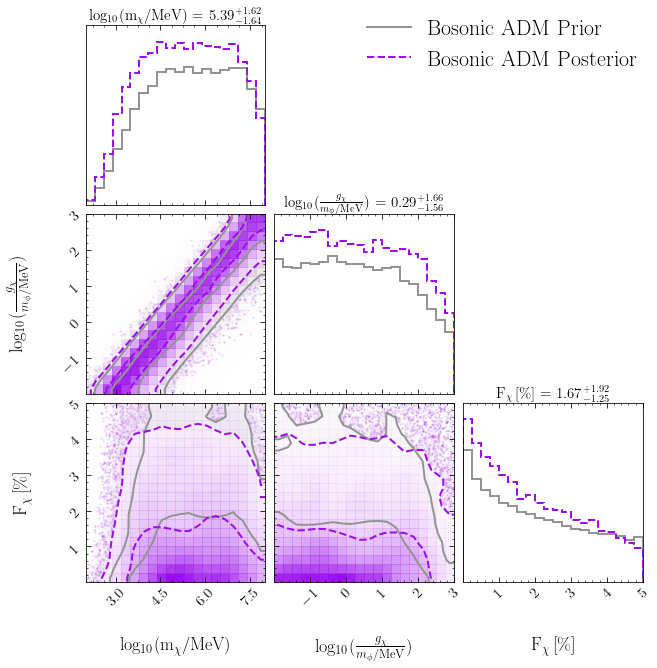

In [15]:
#ADM portion
tmp = numpy.loadtxt('BDM/Bosonic_prior_post_equal_weights.dat')
print('Generating the prior corner plot')

print(len(tmp))
Matrix_prior = numpy.zeros((len(tmp),3))

for i in range(len(tmp)):
    Matrix_prior[i] =numpy.log10(tmp[:,5][i]),numpy.log10(tmp[:,6][i]),tmp[:,7][i]
    
    
    
print('Generating the posterior corner plot')


# In[4]:


ewposterior = numpy.loadtxt('BDM/Bosonic_posterior_post_equal_weights.dat')
print(len(ewposterior))


# In[5]:




mchi = ewposterior[:,5]
gchi_over_mphi = ewposterior[:,6]
Fchi = ewposterior[:,7]
epscent_0740 = ewposterior[:,9]
epscent_0030 = ewposterior[:,10]

Matrix = numpy.zeros((len(epscent_0740),3))
###### Everything below this needs to be fixed!####
for i in range(len(epscent_0740)):
    Matrix[i] =numpy.log10(mchi[i]),numpy.log10(gchi_over_mphi[i]),Fchi[i]


Matrix = np.vstack((Matrix,Matrix)) 

ell = corner.corner(Matrix_prior,smooth = 1.0,color = 'xkcd:grey',group = 'prior',range = [(2,8),(-2,3),(0,5.)],
                   plot_datapoints = False,plot_density = True,plot_contours = True,divergences = False, levels=(0.393, 0.864),
                    hist_kwargs = {'linestyle': '-','linewidth': 2.0}, contour_kwargs = {'linestyles':'solid','linewidths': 2.0})


figure = corner.corner(Matrix,smooth = 1.0,fig = ell,color = c_bosonic,labels = [r"log$_{10}$(m$_\chi$/MeV)",r"log$_{10}$($\frac{\mathdefault{g}_\chi}{\mathdefault{m}_\phi/\mathrm{MeV}})$",r"F$_\chi \, [\%]$"],
                      range = [(2,8),(-2,3),(0,5.)],levels=(0.393, 0.864), show_titles = True,label_kwargs = {"fontsize":18,"font":'serif'},title_kwargs = {"fontsize":15},
                      hist_kwargs = {'linestyle': '--','linewidth': 2.0}, contour_kwargs = {'linestyles':'dashed','linewidths': 2.0})
figure.subplots_adjust(right=1.15,top=1.15)

#quantiles =(0.001,0.999)
figure.subplots_adjust(right=1.15,top=1.15)
for ax in figure.get_axes():
    ax.tick_params(axis='both', labelsize=15) 
    
figure.legend(handles =[matplotlib.lines.Line2D([],[],color = 'xkcd:grey',label = 'Bosonic ADM Prior', linestyle = '-', lw=2.0),
                        matplotlib.lines.Line2D([],[],color = c_bosonic,label = 'Bosonic ADM Posterior',linestyle = '--',lw = 2.0)],
                  fontsize = 22,frameon = False,loc = "upper right")


figure.savefig('plots/Posterior_prior_corner_bosonic_adm.pdf',bbox_inches='tight')
    


Posteriors 68%  (-4.94, 0.47, -0.71)
Posteriors 95%  (-4.94, 0.82, -1.42)


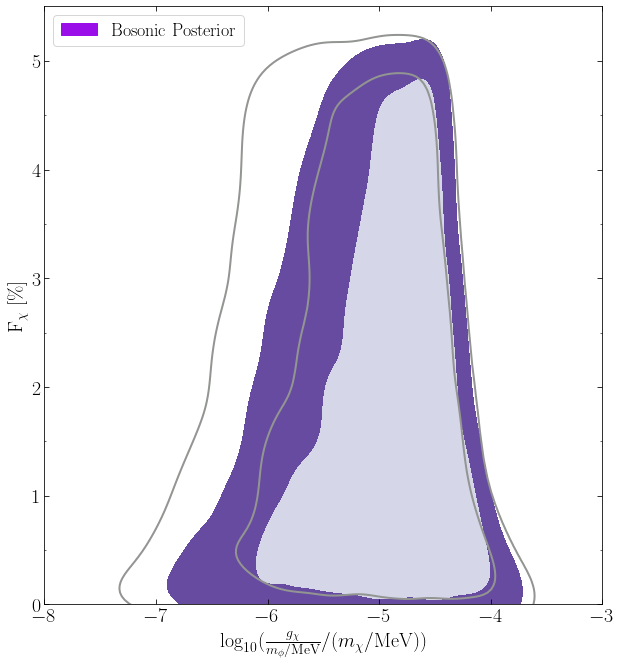

In [16]:
fig,ax = pyplot.subplots(figsize = (10,11))
my_fontsize=20
my_font = 'serif'
matplotlib.rc('font',family = my_font)
matplotlib.rcParams.update({'font.size': 20})
ratio = np.log10(10**Matrix[:,1]/10**Matrix[:,0])

print('Posteriors 68% ', get_quantiles(ratio, quantiles = [0.16,0.5,0.84]) )
print('Posteriors 95% ', get_quantiles(ratio))
plot = sns.kdeplot(x = ratio,y = Matrix[:,2],shade = True,cbar = False,cmap = 'Purples_r'
                   ,common_norm = True,levels=[0.05,0.32,1.],ax = ax)


ratio_prior = np.log10(10**Matrix_prior[:,1]/10**Matrix_prior[:,0])
plot_prior = sns.kdeplot(x = ratio_prior,y = Matrix_prior[:,2],shade = False,cbar = False,
                   colors = 'xkcd:grey',common_norm = True,levels =[0.05,0.32,1],label = "Prior", linestyles = 'solid',
                        linewidths = 2.,ax = ax)




ax.legend(handles =[mpatches.Patch(color = c_bosonic ,label = 'Bosonic Posterior')],
                  fontsize = 18,frameon = True,loc = "upper left")


ax.set_ylim(0.0,5.5)
ax.set_xlim(-8,-3)
ax.set_yticks(numpy.arange(0, 5.5,.5),minor =True)
ax.set_xticks([-8,-7,-6,-5,-4,-3], minor = True)
ax.set_ylabel(r"F$_\chi$ [$\%$]",fontsize=my_fontsize,font = my_font)
ax.set_xlabel(r"$\log_{10}(\frac{\mathdefault{g}_\chi}{\mathdefault{m}_\phi/\mathrm{MeV}}/(\mathdefault{m}_\chi/\mathrm{MeV}))$",fontsize=my_fontsize,font = my_font)
ax.tick_params(top=1,right=1, which='both', direction='in', labelsize=my_fontsize)



fig.savefig('plots/bosonic_adm_ratio_plot.pdf',bbox_inches='tight')

In [ ]:
# Baryonic EoS parameters with dark energy and bosonic ADM

ewposterior_1 = numpy.loadtxt('BDM/Bosonic_posterior_post_equal_weights.dat')

ewposterior_2 = numpy.loadtxt('FDM/Fermionic_posterior_post_equal_weights.dat')

ewposterior_3 = numpy.loadtxt('DE/Dark_energy_posterior_post_equal_weights.dat')


print(ewposterior_2[:,[0,1,2,3]])


# In[5]:



bosonic = corner.corner(ewposterior_1[:,[0,1,2,3,4,8,9,10]],smooth = 1.0,color = 'xkcd:violet',group = 'posterior',
                        range = [(1,4.5),(0,8),(0.5,8),(1.5,8.3),(1.5,8.3),(1.676,2.814),(14,15.5),(14,15.5)],
                   plot_datapoints = False,plot_density = True,plot_contours = True,divergences = False,
                    hist_kwargs = {'linestyle': '--','linewidth': 2.0}, contour_kwargs = {'linestyles':'dashed','linewidths': 2.0})


fermionic = corner.corner(ewposterior_2[:,[0,1,2,3,4,8,9,10]],fig = bosonic,smooth = 1.0,color = 'xkcd:azure',group = 'posterior',
                        range = [(1,4.5),(0,8),(0.5,8),(1.5,8.3),(1.5,8.3),(1.676,2.814),(14,15.5),(14,15.5)],
                   plot_datapoints = False,plot_density = True,plot_contours = True,divergences = False,
                    hist_kwargs = {'linestyle': 'dotted','linewidth': 3.0}, contour_kwargs = {'linestyles':'dotted','linewidths': 3.0})

figure = corner.corner(ewposterior_3[:,[0,1,2,3,4,8,9,10]],smooth = 1.0,fig = fermionic, color = '#E76F51',
                       labels = [r"$\Gamma_1$",r"$\Gamma_2$", r"$\Gamma_3$",r"$\rho_{t,1}[n_0]$",r"$\rho_{t,2}[n_0]$", r"$K_{\rm cEFT}$",r"$\epsilon_{\rm 0740}$",r"$\epsilon_{\rm 0030}$"],
                      range = [(1,4.5),(0,8),(0.5,8),(1.5,8.3),(1.5,8.3),(1.676,2.814),(14,15.5),(14,15.5)], 
                       hist_kwargs = {'linestyle': '-.','linewidth': 2.0}, contour_kwargs = {'linestyles':'dashdot','linewidths': 2.0},
                       show_titles = True,label_kwargs = {"fontsize":20,"font":'serif'},title_kwargs = {"fontsize":20})
figure.subplots_adjust(right=1.15,top=1.15)

#quantiles =(0.001,0.999)
figure.subplots_adjust(right=1.15,top=1.15)
for ax in figure.get_axes():
    ax.tick_params(axis='both', labelsize=15) 
    
figure.legend(handles =[matplotlib.lines.Line2D([],[],color = '#E76F51',label = 'CDF', linestyle = '-.', lw = 2.0),
                        matplotlib.lines.Line2D([],[],color = 'xkcd:violet',label = 'Bosnonic ADM',linestyle = '--',lw = 2.0),
                       matplotlib.lines.Line2D([],[],color = 'xkcd:azure',label = 'Fermionic ADM', linestyle = 'dotted', lw = 3.0),],
                  fontsize = 28,frameon = False,loc = "upper right")


figure.savefig('Posterior_prior_corner_de_bdm_fdm.pdf',bbox_inches='tight')